# gRPC Concurrency Recon

Compare latency and throughput across different  different gRPC semaphore configuration (`GRPC_CONCURRENCY_LIMIT`) to find the optimal setting.

- Signing latency (`signing_started_at` to `signed_at`): Represents the time taken for signature generation, excluding the time spent queued while waiting for semaphore lock acquisition.
- End-to-end latency (`created_at` to `confirmed_at`): Represents the time taken for complete transaction processing, from the moment a request arrives at the system until the transaction is confirmed in a block.
- TPS (overall confirmations / total time span): Represents system throughput.

The optimal setting minimises e2e latency and maximises TPS without overloading signers.

---
### 1. Init

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from faultlab.analysis import merge_run_results, summarise_run, aggregate_summaries

# == Plotting =====================================================================
sns.set_theme(style="whitegrid")

# == Paths =====================================================================
PROJECT_ROOT_DIR = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT_DIR.joinpath("src")))

RESULTS_DIR = PROJECT_ROOT_DIR.joinpath("tests").joinpath("results")
GRPC_RESULTS_DIR = RESULTS_DIR.joinpath("GRPC_CONCURRENCY_LIMIT")

# 1. Discover & group
groups = merge_run_results(GRPC_RESULTS_DIR)

print(f"Project root : {PROJECT_ROOT_DIR}")
print(f"Results dir  : {RESULTS_DIR}")
print(f"Found {sum(len(v) for v in groups.values())} files across {len(groups)} configuration groups.")


Project root : /Users/kr1sel/Documents/Code/|_MSC_Proj_|/faultlab
Results dir  : /Users/kr1sel/Documents/Code/|_MSC_Proj_|/faultlab/tests/results
Found 60 files across 6 configuration groups.


---
### 2. Per-concurrency analysis

In [ ]:
all_summaries = {}
for prefix, dfs in groups.items():
    limit = int(prefix.rsplit("_", 1)[-1])  # extract config value from prefix
    all_summaries.setdefault(limit, [])
    for df in dfs:
        all_summaries[limit].append(summarise_run(df))

agg_rows = []
for limit, summaries in sorted(all_summaries.items()):
    row = aggregate_summaries(summaries)
    row["semaphore_limit"] = limit
    agg_rows.append(row)

res_df = pd.DataFrame(agg_rows).set_index("semaphore_limit").sort_index()

pd.set_option('display.max_columns', None)
display(res_df)


GRPC Concurrency Limit — Summary Table


,n_runs,total_txs,confirmed_txs,success_rate,overall_tps_mean,overall_tps_std,overall_tps_min,overall_tps_max,e2e_median_s_mean,e2e_median_s_std,e2e_median_s_min,e2e_median_s_max,pure_sign_median_s_mean,pure_sign_median_s_std,pure_sign_median_s_min,pure_sign_median_s_max,signing_queue_median_s_mean,signing_queue_median_s_std,signing_queue_median_s_min,signing_queue_median_s_max,submission_median_s_mean,submission_median_s_std,submission_median_s_min,submission_median_s_max,confirmation_median_s_mean,confirmation_median_s_std,confirmation_median_s_min,confirmation_median_s_max
semaphore_limit,,,,,,,,,,,,,,,,,,,,,,,,,,,,
10,10,10000,10000,100.0,41.301,4.880,27.616,44.163,20.827,3.785,19.121,31.566,0.110,0.022,0.098,0.172,8.761,1.274,7.928,12.320,7.046,1.292,6.223,10.654,3.903,0.688,3.090,5.455
30,10,10000,10000,100.0,40.631,5.594,25.034,43.635,22.002,4.978,19.040,35.909,0.297,0.065,0.272,0.481,7.727,1.281,7.116,11.350,8.826,2.161,7.871,14.945,4.175,0.928,3.093,6.115
50,10,10000,10000,100.0,40.156,4.160,29.017,43.437,22.005,3.052,19.476,30.423,0.465,0.071,0.419,0.663,7.508,0.702,7.022,9.364,9.207,1.758,8.023,14.000,4.399,0.938,3.213,6.446
100,10,10000,10000,100.0,39.777,4.584,27.733,42.940,22.792,3.426,19.977,31.764,0.903,0.168,0.807,1.372,7.276,0.855,6.786,9.655,9.651,1.867,8.585,14.715,4.856,0.700,3.421,5.735
200,10,10000,10000,100.0,39.098,4.304,28.533,42.873,23.444,3.235,20.520,31.737,1.819,0.305,1.614,2.640,7.626,0.974,6.955,10.162,9.898,1.642,8.633,14.204,5.153,0.669,3.462,5.824
1000,10,10000,10000,100.0,36.563,3.561,30.380,41.618,25.328,2.816,21.851,30.892,7.581,0.927,6.785,9.883,9.753,0.931,8.958,11.935,9.185,1.300,7.570,11.398,6.184,0.835,5.113,7.477


---
### 3. Identify optimal configuration

In [ ]:
best_tps = int(res_df["overall_tps_mean"].idxmax())
best_e2e = int(res_df["e2e_median_s_mean"].idxmin())
best_sign = int(res_df["pure_sign_median_s_mean"].idxmin())
best_queue = int(res_df["signing_queue_median_s_mean"].idxmin())

print("=" * 60)
print(f"  Best TPS (mean)                  ->  GRPC_LIMIT = {best_tps}")
print(f"  Lowest e2e median (mean)         ->  GRPC_LIMIT = {best_e2e}")
print(f"  Lowest pure-sign median (mean)   ->  GRPC_LIMIT = {best_sign}")
print(f"  Lowest full sign median (mean)   ->  GRPC_LIMIT = {best_sign}")
print("=" * 60)


  Best TPS (mean)                  ->  GRPC_LIMIT = 10
  Lowest e2e median (mean)         ->  GRPC_LIMIT = 10
  Lowest pure-sign median (mean)   ->  GRPC_LIMIT = 10
  Lowest full sign median (mean)   ->  GRPC_LIMIT = 10


---
### 4. Plot results

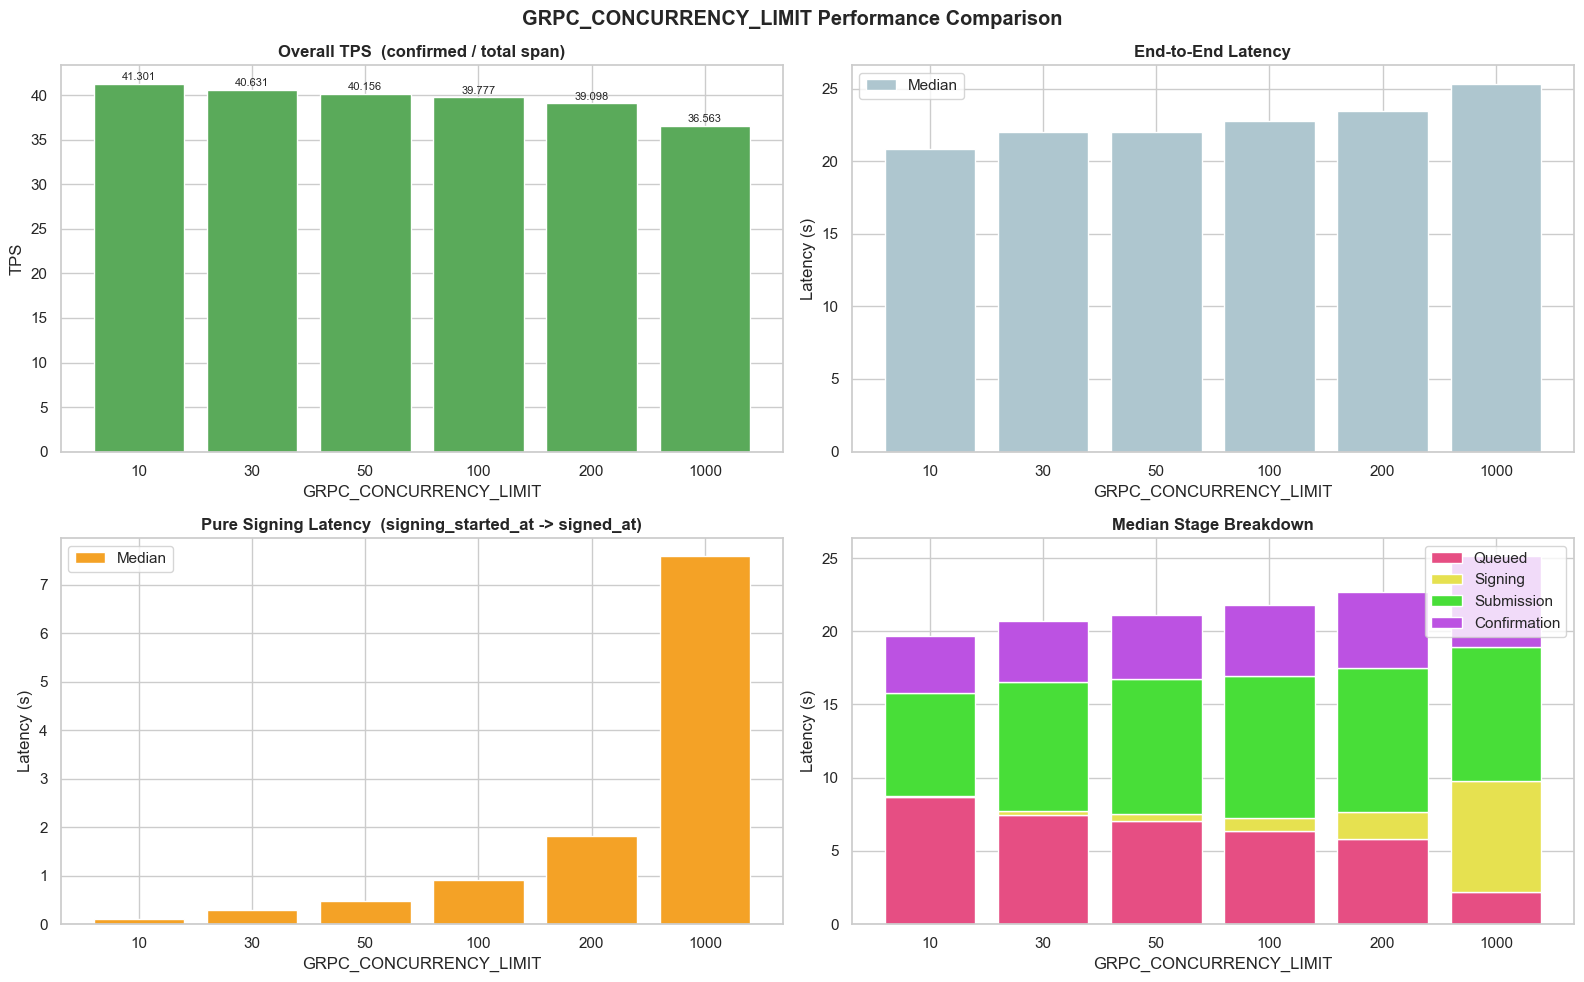

In [ ]:
x_labels = [str(v) for v in res_df.index.tolist()]

_, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1 — Overall TPS
axes[0, 0].bar(x_labels, res_df["overall_tps_mean"], color="#5aaa5a")
axes[0, 0].set_title("Overall TPS  (confirmed / total span)", fontweight="bold")
axes[0, 0].set_xlabel("GRPC_CONCURRENCY_LIMIT")
axes[0, 0].set_ylabel("TPS")
for i, v in enumerate(res_df["overall_tps_mean"]):
    axes[0, 0].text(x=i, y=v + max(res_df["overall_tps_mean"]) * 0.01, s=f"{v:.3f}", ha="center", fontsize=8)

# 2 — E2E latency: median bar
axes[0, 1].bar(x_labels, res_df["e2e_median_s_mean"], color="#aec6cf", label="Median")
axes[0, 1].set_title("End-to-End Latency", fontweight="bold")
axes[0, 1].set_xlabel("GRPC_CONCURRENCY_LIMIT")
axes[0, 1].set_ylabel("Latency (s)")
axes[0, 1].legend()

# 3 — Pure signing latency: median bar
axes[1, 0].bar(x_labels, res_df["pure_sign_median_s_mean"], color="#f4a226", label="Median")
axes[1, 0].set_title("Pure Signing Latency  (signing_started_at -> signed_at)", fontweight="bold")
axes[1, 0].set_xlabel("GRPC_CONCURRENCY_LIMIT")
axes[1, 0].set_ylabel("Latency (s)")
axes[1, 0].legend()

# 4 — Stacked stage breakdown
res_df["queue_wait_s"] = (res_df["signing_queue_median_s_mean"] - res_df["pure_sign_median_s_mean"]).clip(lower=0)
stages        = ["queue_wait_s", "pure_sign_median_s_mean", "submission_median_s_mean", "confirmation_median_s_mean"]
stage_colors  = ["#e64e83", "#e6e150", "#48de38", "#bc52e2"]
stage_labels  = ["Queued", "Signing", "Submission", "Confirmation"]

bottom = pd.Series([0.0] * len(res_df), index=res_df.index)
for col, color, label in zip(stages, stage_colors, stage_labels):
    axes[1, 1].bar(x_labels, res_df[col], bottom=bottom.values, color=color, label=label)
    bottom += res_df[col]
axes[1, 1].set_title("Median Stage Breakdown", fontweight="bold")
axes[1, 1].set_xlabel("GRPC_CONCURRENCY_LIMIT")
axes[1, 1].set_ylabel("Latency (s)")
axes[1, 1].legend()

plt.suptitle("GRPC_CONCURRENCY_LIMIT Performance Comparison", fontweight="bold")
plt.tight_layout()
plt.show()
